Â© 2026 by TamÃ¡s TakÃ¡cs is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

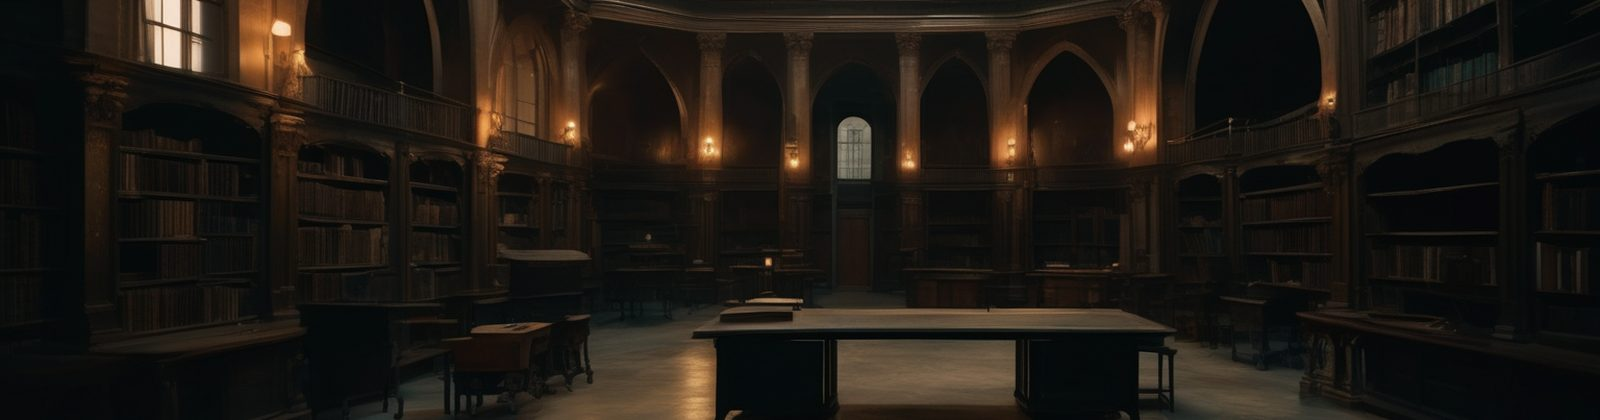

# **The Reading Room (SOLUTION)**

> Organizer reference. Never upload this notebook to DOCK and never hand it to students
> before the session ends.

## **What this is**

`inputs.json` holds one academic year of borrowing from a university library: roughly ninety thousand loans, each recording who borrowed which book, on which day, and for how long.

Three questions are asked about that log. None of them is hard once the data is arranged correctly. Arranging it correctly is the exercise. Every part can be answered by scanning the whole log once per query, and every part is meant to be answered by walking the log once in total.

| Part | Question | Points |
|---|---|---:|
| a | How many loans were out on a given day | 30 |
| b | How many different members have borrowed a given book | 35 |
| c | How many members share a book with a given member | 35 |

Each part wants a CSV with columns `id,target`, one integer per row, scored exact-match: `points * (correct rows / total rows)`. Partial credit is real, so submit what you have.

Part c is easiest to write after part b, because it reuses the same lookup table. Doing the parts in order is the intended route.

## **The data**

```
inputs.json
  loans           a list of [member, book, day, kept]
  n_members       900
  n_books         4000
  n_days          365
  day_queries     30 day numbers, for part a
  book_queries    30 book numbers, for part b
  member_queries  30 member numbers, for part c
```

One entry of `loans` is `[member, book, day, kept]`: member number `member` borrowed book number `book` on day `day` and kept it for `kept` days. All four are integers, all numbering is **0-based**, and `day` runs from 0 to 364.

Members and books are numbered independently, so member 7 and book 7 have nothing to do with one another. The list is in no particular order. The same member may borrow the same book more than once during the year.

**What "out on day d" means.** A book borrowed on day `day` and kept for `kept` days is out of the library on days `day`, `day + 1`, up to and including `day + kept - 1`. It is back on the shelf on day `day + kept`. A loan taken on day 100 and kept for 3 days is out on days 100, 101 and 102, and is not out on day 103.

## **Setup and data**

In [ ]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# Imports. Standard library only this week. DO NOT MODIFY.
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
import csv
import json
from pathlib import Path

def write_submission(filename, rows):
    """Write [(id, target), ...] as a DOCK-ready CSV.

    Every part of every exercise this semester ends with a call like this one.
    """
    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["id", "target"])
        for row_id, target in rows:
            writer.writerow([int(row_id), int(target)])
    print(f"wrote {filename}: {len(rows)} rows")

# Download inputs.json from the exercise page on DOCK and put it next to this
# notebook (in Colab: drag it into the file browser on the left).
_path = Path("inputs.json") if Path("inputs.json").exists() else Path("data/inputs.json")
inputs = json.loads(_path.read_text(encoding="utf-8"))

loans = inputs["loans"]
n_members, n_books, n_days = inputs["n_members"], inputs["n_books"], inputs["n_days"]
day_queries = inputs["day_queries"]
book_queries = inputs["book_queries"]
member_queries = inputs["member_queries"]

print(f"{len(loans)} loans, {n_members} members, {n_books} books, {n_days} days")
print(f"first loan: {loans[0]}  (member, book, day, kept)")
print(f"queries: {len(day_queries)} days, {len(book_queries)} books, "
      f"{len(member_queries)} members")

---
## **Part a: Books out on a given day (30 points)**

For each day `d` in `day_queries`, in the order given, report **how many loans were out on day `d`**.

A loan counts if it started on or before `d` and had not yet been returned, using the definition above.

One thing to notice before you start: `day` runs from 0 to 364, and that is a **small, known range**. Ninety thousand loans do not have to be examined thirty times to answer thirty questions about 365 possible days.

Submission: `part1_submission.csv`, one row per queried day, uploaded to part a.

In [ ]:
# One sweep: +1 on the day a loan starts, -1 on the day it comes back.
# A running total over the days then gives the count out on every day at once.
span = n_days + 40
delta = [0] * span
for member, book, day, kept in loans:
    delta[day] += 1
    delta[min(day + kept, span - 1)] -= 1

out_on, running = [], 0
for d in range(span):
    running += delta[d]
    out_on.append(running)

part1 = [(i, out_on[d]) for i, d in enumerate(day_queries)]

write_submission("part1_submission.csv", part1)
part1[:5]

---
## **Part b: Different borrowers of a book (35 points)**

For each book `b` in `book_queries`, in the order given, report **how many different members have borrowed book `b`** at any point in the year.

Different members, not loans. A member who borrowed the same book in October and again in March is one member, and every book in this list was borrowed twice by somebody, so the two numbers are never the same.

Submission: `part2_submission.csv`, one row per queried book, uploaded to part b.

In [ ]:
# One pass builds the whole table; the queries are then lookups.
members_of = {}
for member, book, day, kept in loans:
    members_of.setdefault(book, set()).add(member)

part2 = [(i, len(members_of.get(b, ()))) for i, b in enumerate(book_queries)]

write_submission("part2_submission.csv", part2)
part2[:5]

---
## **Part c: Members who share a book (35 points)**

Two members are **reading neighbours** if there is at least one book that both of them borrowed at some point in the year. It does not matter when, and it does not matter how many books they share: one is enough.

For each member `m` in `member_queries`, in the order given, report **how many other members are reading neighbours of `m`**. A member is never their own neighbour, so do not count `m` itself.

Comparing every member against every other member is 900 by 900 comparisons, each of which compares two sets of books. The table you built in part b already says, for any book, exactly who borrowed it.

Submission: `part3_submission.csv`, one row per queried member, uploaded to part c.

In [ ]:
# Two indexes, both from the same single pass.
members_of, books_of = {}, {}
for member, book, day, kept in loans:
    members_of.setdefault(book, set()).add(member)
    books_of.setdefault(member, set()).add(book)

part3 = []
for i, m in enumerate(member_queries):
    neighbours = set()
    for book in books_of.get(m, ()):
        neighbours |= members_of[book]
    neighbours.discard(m)
    part3.append((i, len(neighbours)))

write_submission("part3_submission.csv", part3)
part3[:5]

In [ ]:
# â”€â”€ Evaluator reproduction: mirrors grader/_common.py exactly â”€â”€
def exact_match_points(rows, solution_csv, max_score):
    with open(solution_csv, newline="", encoding="utf-8") as f:
        gt = {int(r["id"]): int(r["target"]) for r in csv.DictReader(f)}
    submitted = {int(i): int(t) for i, t in rows}
    assert set(submitted) == set(gt), "id set mismatch"
    correct = sum(1 for k in gt if submitted[k] == gt[k])
    return int(round(correct / len(gt) * max_score))


total = 0
for n, rows, mx in ((1, part1, 30), (2, part2, 35), (3, part3, 35)):
    pts = exact_match_points(rows, f"grader/{n}_solution.csv", mx)
    total += pts
    print(f"part {n}: {pts}/{mx}")
print(f"total:  {total}/100")

---
## **Before you leave**

Upload each CSV to its own part on DOCK.

